In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

PHASE 1

In [2]:
df = pd.read_csv('final_loan_default_dataset.csv')
df

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Payment_History,Savings_Balance,Loan_Purpose,Default
0,CUST00000,59,Male,Single,High School,Unemployed,153435,57032,36,337,0,0.16,Poor,3594,Car,1
1,CUST00001,49,Male,Single,Bachelor,Unemployed,1358590,753454,24,799,3,0.52,Average,77610,Business,1
2,CUST00002,35,Male,Married,Bachelor,Employed,864995,350178,60,342,1,0.22,Average,189727,Home,1
3,CUST00003,63,Male,Married,Master,Unemployed,862917,676946,12,816,1,0.66,Good,421647,Education,1
4,CUST00004,28,Female,Married,High School,Unemployed,525601,957555,24,367,1,0.23,Average,214756,Home,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CUST01995,54,Female,Married,PhD,Unemployed,523221,969156,36,881,2,0.13,Average,270189,Car,0
1996,CUST01996,38,Male,Married,Master,Employed,1184023,486841,48,832,2,0.53,Poor,306399,Car,1
1997,CUST01997,33,Male,Married,High School,Self-Employed,946060,308466,24,434,1,0.65,Average,52965,Education,1
1998,CUST01998,61,Female,Single,High School,Unemployed,543545,529198,60,410,4,0.31,Poor,264381,Personal,1


In [3]:
print("Shape of dataset:",df.shape)

Shape of dataset: (2000, 16)


In [4]:
print("Size of dataset:",df.size)

Size of dataset: 32000


In [5]:
#Understanding the structure of dataset
df.describe()

,Age,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Savings_Balance,Default
count,2000.000000,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,42.694000,8.299711e+05,525997.057000,36.354000,596.964000,1.974500,0.400720,247342.831500,0.69550
std,12.614195,3.862774e+05,272378.273758,17.087442,171.731356,1.420161,0.171901,143678.727557,0.46031
min,21.000000,1.500370e+05,50799.000000,12.000000,300.000000,0.000000,0.100000,1056.000000,0.00000
25%,32.000000,5.106692e+05,296489.750000,24.000000,452.000000,1.000000,0.250000,124489.250000,0.00000
50%,43.000000,8.314425e+05,525436.000000,36.000000,593.000000,2.000000,0.400000,249331.000000,1.00000
75%,54.000000,1.153992e+06,770494.000000,48.000000,748.000000,3.000000,0.542500,369349.250000,1.00000
max,64.000000,1.499987e+06,999500.000000,60.000000,899.000000,4.000000,0.700000,499901.000000,1.00000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           2000 non-null   object 
 1   Age                   2000 non-null   int64  
 2   Gender                2000 non-null   object 
 3   Marital_Status        2000 non-null   object 
 4   Education_Level       2000 non-null   object 
 5   Employment_Status     2000 non-null   object 
 6   Annual_Income         2000 non-null   int64  
 7   Loan_Amount           2000 non-null   int64  
 8   Loan_Term_Months      2000 non-null   int64  
 9   Credit_Score          2000 non-null   int64  
 10  Existing_Loans_Count  2000 non-null   int64  
 11  Debt_to_Income_Ratio  2000 non-null   float64
 12  Payment_History       2000 non-null   object 
 13  Savings_Balance       2000 non-null   int64  
 14  Loan_Purpose          2000 non-null   object 
 15  Default              

In [7]:
#Counting total null values in each column using null function
print("Total null values in each column:",df.isna().sum())
#Counting total null values in dataset
print("Total null values in dataset:",df.isna().sum().sum())

Total null values in each column: Customer_ID             0
Age                     0
Gender                  0
Marital_Status          0
Education_Level         0
Employment_Status       0
Annual_Income           0
Loan_Amount             0
Loan_Term_Months        0
Credit_Score            0
Existing_Loans_Count    0
Debt_to_Income_Ratio    0
Payment_History         0
Savings_Balance         0
Loan_Purpose            0
Default                 0
dtype: int64
Total null values in dataset: 0


In [8]:
#Checking for duplicates
print("Duplicated rows:",df.duplicated().sum())

Duplicated rows: 0


In [9]:
#Checking necessary features needed
print("Column names:\n",df.columns)
df.head()

Column names:
 Index(['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Education_Level',
       'Employment_Status', 'Annual_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_Score', 'Existing_Loans_Count', 'Debt_to_Income_Ratio',
       'Payment_History', 'Savings_Balance', 'Loan_Purpose', 'Default'],
      dtype='object')


,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Payment_History,Savings_Balance,Loan_Purpose,Default
0,CUST00000,59,Male,Single,High School,Unemployed,153435,57032,36,337,0,0.16,Poor,3594,Car,1
1,CUST00001,49,Male,Single,Bachelor,Unemployed,1358590,753454,24,799,3,0.52,Average,77610,Business,1
2,CUST00002,35,Male,Married,Bachelor,Employed,864995,350178,60,342,1,0.22,Average,189727,Home,1
3,CUST00003,63,Male,Married,Master,Unemployed,862917,676946,12,816,1,0.66,Good,421647,Education,1
4,CUST00004,28,Female,Married,High School,Unemployed,525601,957555,24,367,1,0.23,Average,214756,Home,1


In [10]:
#Dropping columns which are not required
df=df.drop(columns = ['Customer_ID','Gender'])

In [11]:
df

,Age,Marital_Status,Education_Level,Employment_Status,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loans_Count,Debt_to_Income_Ratio,Payment_History,Savings_Balance,Loan_Purpose,Default
0,59,Single,High School,Unemployed,153435,57032,36,337,0,0.16,Poor,3594,Car,1
1,49,Single,Bachelor,Unemployed,1358590,753454,24,799,3,0.52,Average,77610,Business,1
2,35,Married,Bachelor,Employed,864995,350178,60,342,1,0.22,Average,189727,Home,1
3,63,Married,Master,Unemployed,862917,676946,12,816,1,0.66,Good,421647,Education,1
4,28,Married,High School,Unemployed,525601,957555,24,367,1,0.23,Average,214756,Home,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,54,Married,PhD,Unemployed,523221,969156,36,881,2,0.13,Average,270189,Car,0
1996,38,Married,Master,Employed,1184023,486841,48,832,2,0.53,Poor,306399,Car,1
1997,33,Married,High School,Self-Employed,946060,308466,24,434,1,0.65,Average,52965,Education,1
1998,61,Single,High School,Unemployed,543545,529198,60,410,4,0.31,Poor,264381,Personal,1


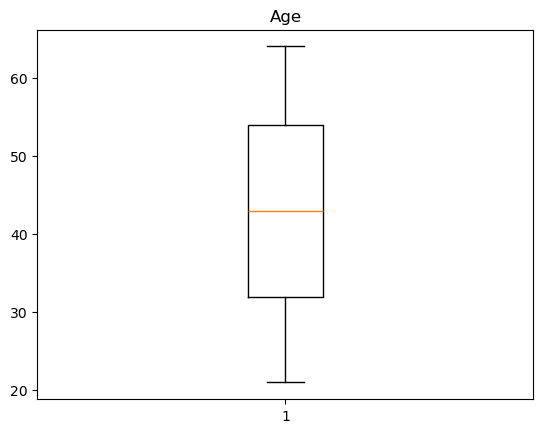

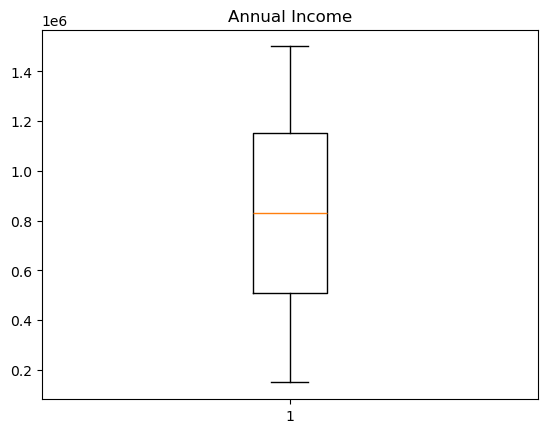

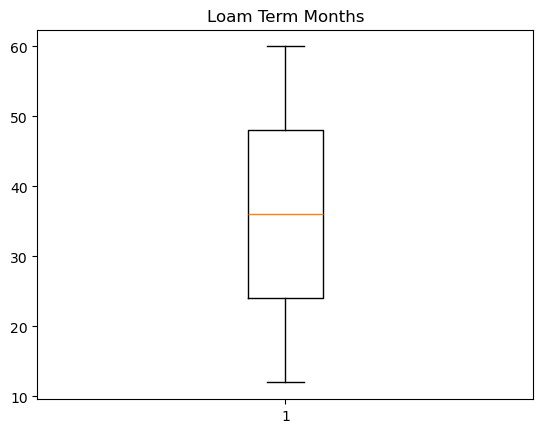

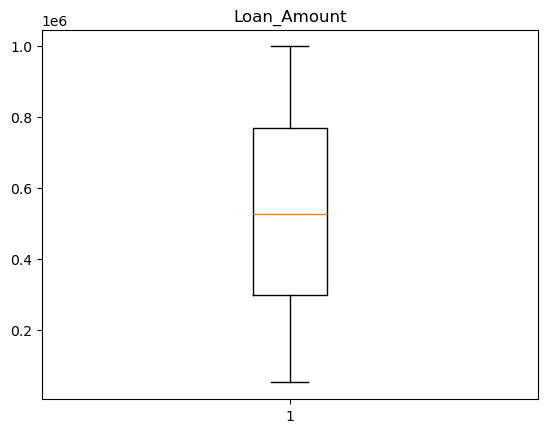

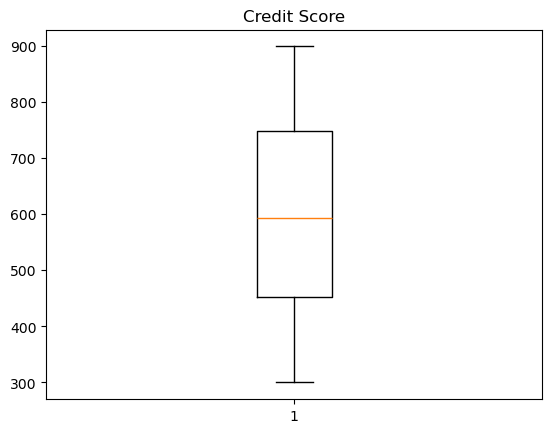

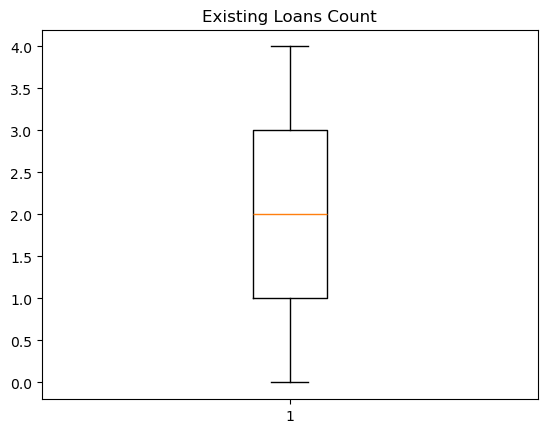

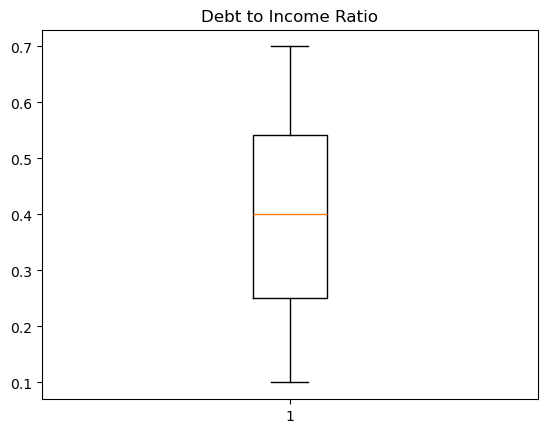

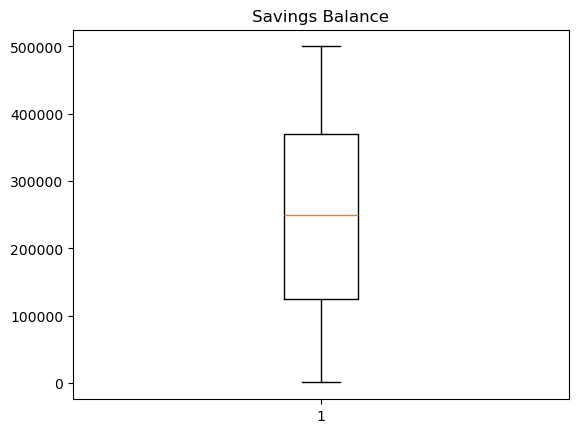

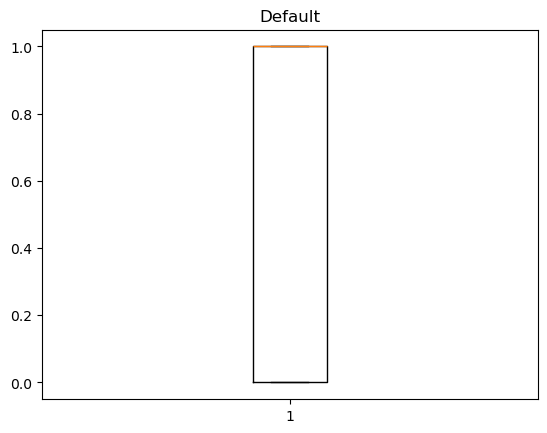

In [12]:
#Outlier Detection by boxplot

plt.boxplot(df['Age'])
plt.title('Age')
plt.show()

plt.boxplot(df['Annual_Income'])
plt.title('Annual Income')
plt.show()

plt.boxplot(df['Loan_Term_Months'])
plt.title('Loam Term Months')
plt.show()

plt.boxplot(df['Loan_Amount'])
plt.title('Loan_Amount')
plt.show()

plt.boxplot(df['Credit_Score'])
plt.title('Credit Score')
plt.show()

plt.boxplot(df['Existing_Loans_Count'])
plt.title('Existing Loans Count')
plt.show()

plt.boxplot(df['Debt_to_Income_Ratio'])
plt.title('Debt to Income Ratio')
plt.show()

plt.boxplot(df['Savings_Balance'])
plt.title('Savings Balance')
plt.show()

plt.boxplot(df['Default'])
plt.title('Default')
plt.show()

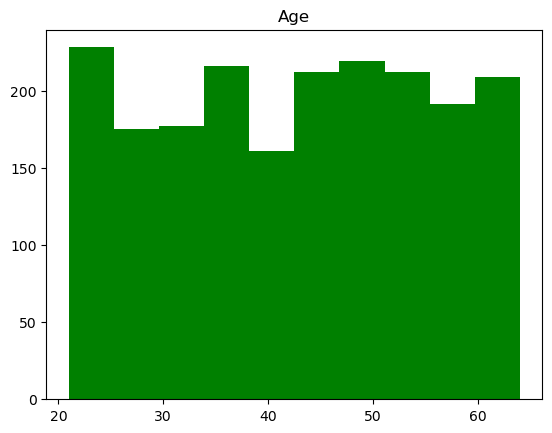

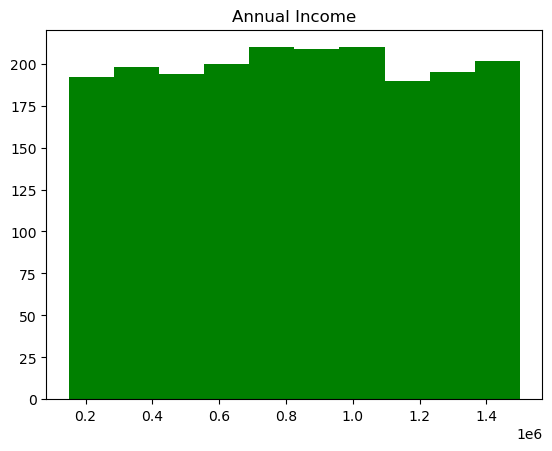

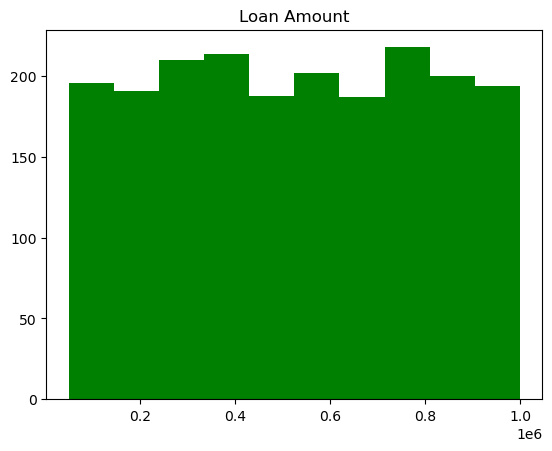

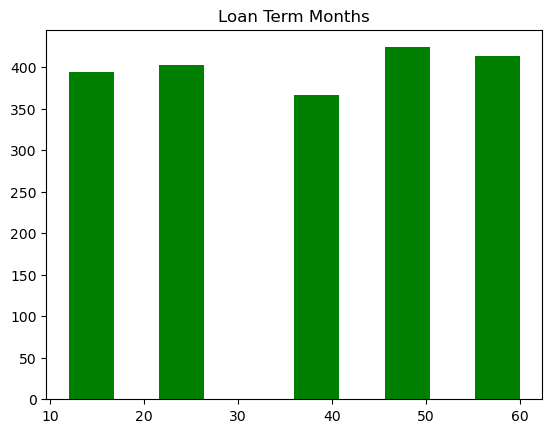

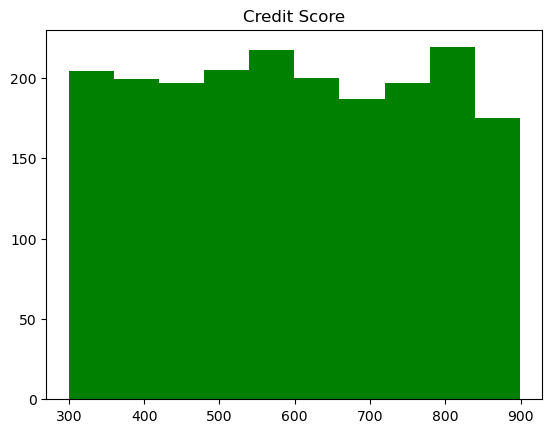

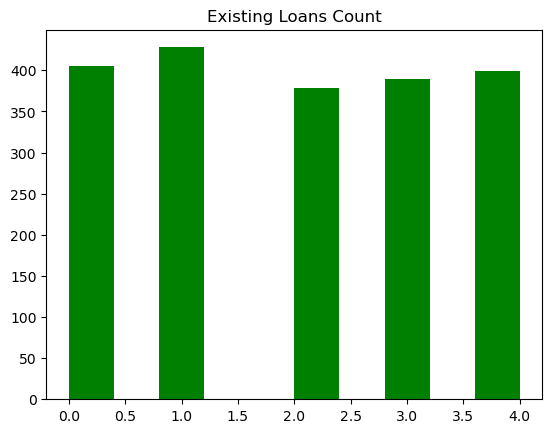

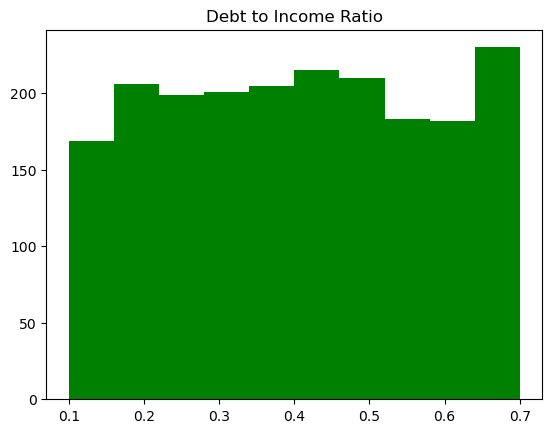

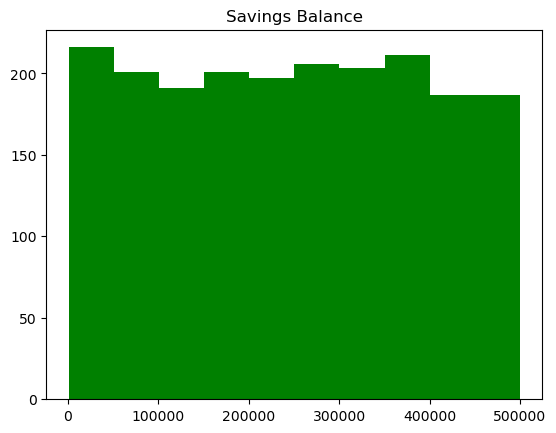

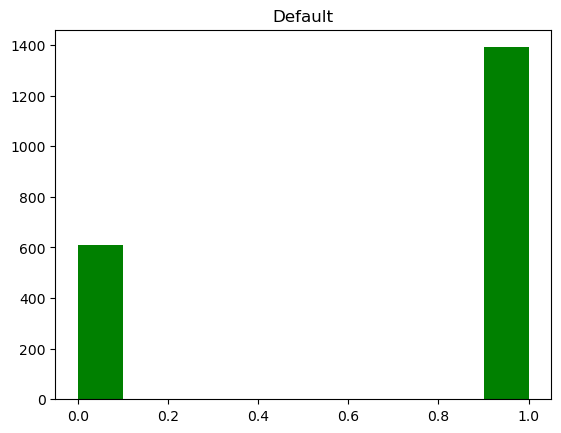

In [13]:
#Checking data distribution by histogram

plt.hist(df['Age'],color='g')
plt.title('Age')
plt.show()

plt.hist(df['Annual_Income'],color='g')
plt.title('Annual Income')
plt.show()

plt.hist(df['Loan_Amount'],color='g')
plt.title('Loan Amount')
plt.show()

plt.hist(df['Loan_Term_Months'],color='g')
plt.title('Loan Term Months')
plt.show()

plt.hist(df['Credit_Score'],color='g')
plt.title('Credit Score')
plt.show()

plt.hist(df['Existing_Loans_Count'],color='g')
plt.title('Existing Loans Count')
plt.show()

plt.hist(df['Debt_to_Income_Ratio'],color='g')
plt.title('Debt to Income Ratio')
plt.show()

plt.hist(df['Savings_Balance'],color='g')
plt.title('Savings Balance')
plt.show()

plt.hist(df['Default'],color='g')
plt.title('Default')
plt.show()

In [14]:
#Scaling the features using MinMaxScaler
mm = MinMaxScaler()
normalized_data = pd.DataFrame(mm.fit_transform(df[['Annual_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_Score', 'Existing_Loans_Count', 'Debt_to_Income_Ratio', 'Savings_Balance']]))

normalized_data

,0,1,2,3,4,5,6
0,0.002517,0.006570,0.50,0.061770,0.00,0.100000,0.005088
1,0.895258,0.740650,0.25,0.833055,0.75,0.700000,0.153462
2,0.529618,0.315567,1.00,0.070117,0.25,0.200000,0.378216
3,0.528079,0.660005,0.00,0.861436,0.25,0.933333,0.843130
4,0.278206,0.955787,0.25,0.111853,0.25,0.216667,0.428390
...,...,...,...,...,...,...,...
1995,0.276443,0.968015,0.50,0.969950,0.50,0.050000,0.539512
1996,0.765944,0.459620,0.75,0.888147,0.50,0.716667,0.612100
1997,0.589669,0.271600,0.25,0.223706,0.25,0.916667,0.104058
1998,0.291498,0.504267,1.00,0.183639,1.00,0.350000,0.527869


In [15]:
#Naming scaled columns using rename function

print("Scaled data:\n")

normalized_data.rename(columns={0:'Annual_Income',
1:'Loan_Amount',
2:'Loan_Term_Months',
3:'Credit_Score',
4:'Existing_Loan_Count',
5:'Debt_to_Income_Ratio',
6:'Savings_Balance'},inplace = True)

normalized_data.head()

Scaled data:



,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loan_Count,Debt_to_Income_Ratio,Savings_Balance
0,0.002517,0.006570,0.50,0.061770,0.00,0.100000,0.005088
1,0.895258,0.740650,0.25,0.833055,0.75,0.700000,0.153462
2,0.529618,0.315567,1.00,0.070117,0.25,0.200000,0.378216
3,0.528079,0.660005,0.00,0.861436,0.25,0.933333,0.843130
4,0.278206,0.955787,0.25,0.111853,0.25,0.216667,0.428390


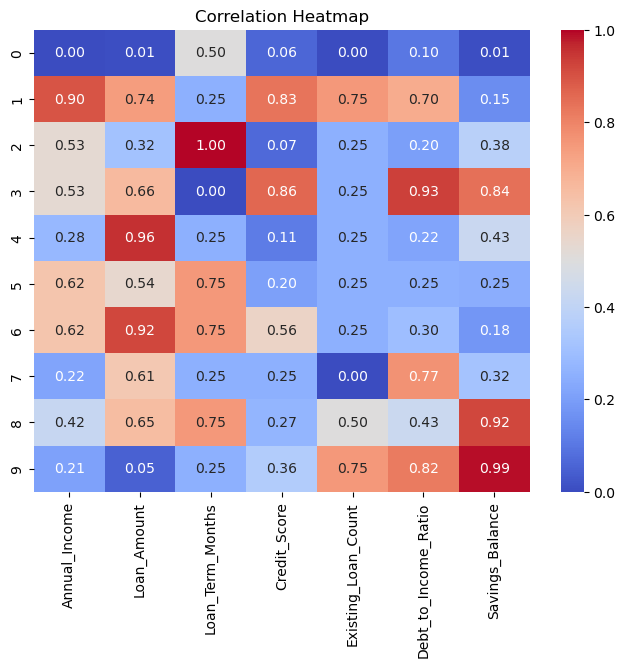

In [26]:
# correlation matrix
corr = normalized_data.head(10)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [40]:
#Using train test split by using Scaled data
X = normalized_data
Y = df['Default']
Y

0       1
1       1
2       1
3       1
4       1
       ..
1995    0
1996    1
1997    1
1998    1
1999    1
Name: Default, Length: 2000, dtype: int64

In [34]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

print("Successfully Executed")

Successfully Executed


PHASE 2

In [28]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV

In [60]:
#Hyperparameter Tuning to find best value of k
param_knn = {
    'n_neighbors':[3, 5, 7, 9, 11],
    'weights':['uniform', 'distance'],
    'metric':['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)
grid_knn.fit(X_train,Y_train)   

print('Best KNN Parameters:', grid_knn.best_params_)

Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}


In [61]:
#Model training with the help of KNeighborsClassifier
Model1 = KNeighborsClassifier(n_neighbors = 11)

In [62]:
Model1.fit(X_train,Y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [63]:
#Checking the prediction of the model
Y_pred = Model1.predict(X_test)
print("Predicted Values:\n",Y_pred)

Predicted Values:
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1
 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0
 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 1 1 1 1
 1 1 0 1 1 0 1 0 1 1 0 1 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 1 0 0 1
 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1
 1 0 0 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0
 1 0 1 1 1 1 0 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 0
 1 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1 1 1 0 1 1 0 1 1
 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 0]


In [64]:
#Checking scores of KNeighborsClassifier model
F1 = f1_score(Y_test,Y_pred)
P = precision_score(Y_test,Y_pred)
R = recall_score(Y_test,Y_pred)
CM = confusion_matrix(Y_test,Y_pred)

In [65]:
print(f"Precision score:{P}")

Precision score:0.7731958762886598


In [66]:
print(f"Recall score:{R}")

Recall score:0.8490566037735849


In [67]:
print(f"F1 score:{F1}")

F1 score:0.8093525179856115


In [68]:
print("Confusion matrix:\n",CM)

Confusion matrix:
 [[ 69  66]
 [ 40 225]]


In [69]:
print("Classification reports of KNeighborsClassifier:\n", classification_report(Y_test,Y_pred))

Classification reports of KNeighborsClassifier:
               precision    recall  f1-score   support

           0       0.63      0.51      0.57       135
           1       0.77      0.85      0.81       265

    accuracy                           0.73       400
   macro avg       0.70      0.68      0.69       400
weighted avg       0.73      0.73      0.73       400



In [70]:
#Training our model through logistic regression
Model2 = LogisticRegression()

In [71]:
Model2.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
Y_pred1 = Model2.predict(X_test)
print("Predicted Values:\n",Y_pred1)

Predicted Values:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1
 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0
 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1
 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1
 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0
 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 1 0]


In [79]:
print("Classification reports of LogisticRegression:\n", classification_report(Y_test,Y_pred1))

Classification reports of LogisticRegression:
               precision    recall  f1-score   support

           0       0.70      0.44      0.54       135
           1       0.76      0.91      0.83       265

    accuracy                           0.75       400
   macro avg       0.73      0.67      0.68       400
weighted avg       0.74      0.75      0.73       400



In [80]:
print("Confusion matrix\n",CM)

Confusion matrix
 [[ 69  66]
 [ 40 225]]


In [83]:
#Using Standard scaler for model trainig
from sklearn.preprocessing import StandardScaler

In [84]:
ss = StandardScaler()
standardized_data = pd.DataFrame(ss.fit_transform(df[['Annual_Income', 'Loan_Amount', 'Loan_Term_Months',
       'Credit_Score', 'Existing_Loans_Count', 'Debt_to_Income_Ratio', 'Savings_Balance']]))
standardized_data

,0,1,2,3,4,5,6
0,-1.751864,-1.722172,-0.020722,-1.514162,-1.390683,-1.400691,-1.696909
1,1.368838,0.835286,-0.723168,1.176760,0.722282,0.694061,-1.181631
2,0.090693,-0.645657,1.384169,-1.485039,-0.686361,-1.051566,-0.401105
3,0.085312,0.554327,-1.425614,1.275776,-0.686361,1.508687,1.213456
4,-0.788154,1.584803,-0.723168,-1.339426,-0.686361,-0.993378,-0.226860
...,...,...,...,...,...,...,...
1995,-0.794317,1.627405,-0.020722,1.654369,0.017960,-1.575254,0.159048
1996,0.916804,-0.143792,0.681724,1.368968,0.017960,0.752249,0.411132
1997,0.300608,-0.798836,-0.723168,-0.949185,-0.686361,1.450500,-1.353203
1998,-0.741689,0.011755,1.384169,-1.088973,1.426603,-0.527878,0.118615


In [85]:
#Renaming columns
print("Scaled data:\n")

standardized_data.rename(columns={
0:'Annual_Income',
1:'Loan_Amount',
2:'Loan_Term_Months',
3:'Credit_Score',
4:'Existing_Loan_Count',
5:'Debt_to_Income_Ratio',
6:'Savings_Balance'},inplace = True)

standardized_data.head()

Scaled data:



,Annual_Income,Loan_Amount,Loan_Term_Months,Credit_Score,Existing_Loan_Count,Debt_to_Income_Ratio,Savings_Balance
0,-1.751864,-1.722172,-0.020722,-1.514162,-1.390683,-1.400691,-1.696909
1,1.368838,0.835286,-0.723168,1.176760,0.722282,0.694061,-1.181631
2,0.090693,-0.645657,1.384169,-1.485039,-0.686361,-1.051566,-0.401105
3,0.085312,0.554327,-1.425614,1.275776,-0.686361,1.508687,1.213456
4,-0.788154,1.584803,-0.723168,-1.339426,-0.686361,-0.993378,-0.226860


In [86]:
#Using train_test_split on standardized data
Xs = standardized_data
Y = df['Default']
Y

0       1
1       1
2       1
3       1
4       1
       ..
1995    0
1996    1
1997    1
1998    1
1999    1
Name: Default, Length: 2000, dtype: int64

In [87]:
Xs_train,Xs_test,Ys_train,Ys_test = train_test_split(Xs,Y,test_size = 0.2, random_state = 42)

print("Successfully executed.")

Successfully executed.


In [88]:
#Training model by KNeighborsClassifier
Models = KNeighborsClassifier(n_neighbors = 11)

In [89]:
Models.fit(Xs_train,Ys_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [90]:
Ys_pred = Models.predict(X_test)
print("Predicted Values:\n",Ys_pred)

Predicted Values:
 [0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 0 1 0
 1 1 0 1 0 0 1 1 1 1 1 1 1 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 1 0 0 0 1 0 0 1 1
 1 1 1 1 1 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 0 0 1 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1
 0 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0 1 0 0 0 1 1 0 0 1
 0 1 1 1 0 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1
 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0
 1 1 1 0 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 0 1 0 1 1
 0 1 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 1]


In [91]:
#EVALUATING THE SCORES
print("Precision score:", precision_score(Ys_test,Ys_pred))

Precision score: 0.7222222222222222


In [92]:
print("Accuracy:", accuracy_score(Ys_test,Ys_pred))

Accuracy: 0.6375


In [93]:
print("Recall score:",recall_score(Ys_test,Ys_pred))

Recall score: 0.7358490566037735


In [94]:
print("F1 score:",f1_score(Ys_test,Ys_pred))

F1 score: 0.7289719626168224


In [95]:
print("Classification report:\n", classification_report(Ys_test,Ys_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.46      0.44      0.45       135
           1       0.72      0.74      0.73       265

    accuracy                           0.64       400
   macro avg       0.59      0.59      0.59       400
weighted avg       0.63      0.64      0.64       400



In [96]:
print("Confusion matrix:\n",confusion_matrix(Ys_test,Ys_pred))

Confusion matrix:
 [[ 60  75]
 [ 70 195]]


In [97]:
#Training model by LogisticRegression
Models1 = LogisticRegression()

In [98]:
Models1.fit(Xs_train,Ys_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [99]:
Ys1_pred = Models1.predict(Xs_test)
print("Predicted Values:\n",Ys1_pred)

Predicted Values:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1
 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0
 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1
 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 1 1 1 0 0 1
 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 0 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0
 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 1 0]


In [100]:
#EVALUATING THE SCORES
print("Precision score:", precision_score(Ys_test,Ys1_pred))

Precision score: 0.7692307692307693


In [101]:
print("Accuracy:", accuracy_score(Ys_test,Ys1_pred))

Accuracy: 0.7575


In [102]:
print("Recall score:",recall_score(Ys_test,Ys1_pred))

Recall score: 0.9056603773584906


In [103]:
print("F1 score:",f1_score(Ys_test,Ys1_pred))

F1 score: 0.8318890814558059


In [104]:
print("Classification report:\n", classification_report(Ys_test,Ys1_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.72      0.47      0.57       135
           1       0.77      0.91      0.83       265

    accuracy                           0.76       400
   macro avg       0.74      0.69      0.70       400
weighted avg       0.75      0.76      0.74       400



In [105]:
print("Confusion matrix:\n",confusion_matrix(Ys_test,Ys1_pred))

Confusion matrix:
 [[ 63  72]
 [ 25 240]]


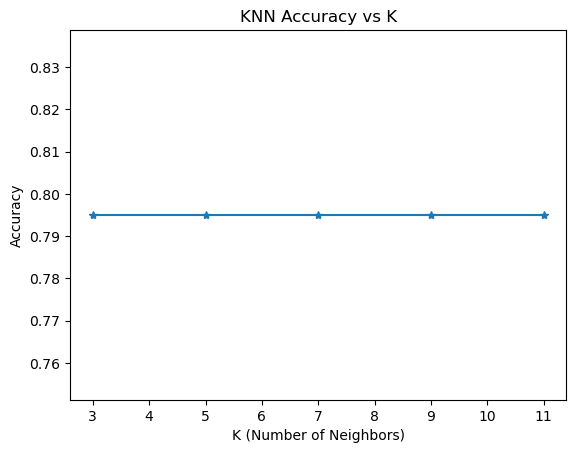

In [114]:
k_values = [3,5,7,9,11]
accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    accuracy.append(accuracy_score(Y_test, Y_pred))

plt.plot(k_values, accuracy, marker='*')
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

PHASE 3

In [106]:
#Using libraries needed
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [38]:
#Hyperparameter Tuning to find best value of k
from sklearn.model_selection import GridSearchCV
param_knn = {
    'n_neighbors':[3, 5, 7, 9, 11],
    'weights':['uniform', 'distance'],
    'metric':['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)

grid_knn.fit(X_train,Y_train)

print('Best KNN Parameters:', grid_knn.best_params_)

Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}


In [39]:
#Using Hyperparameter tuning in Decision Tree
grid_dtc = GridSearchCV(
    DecisionTreeClassifier(random_state=42),{'max_depth': [3,5,7,10,None], 'min_samples_split': [2,5,10], 'criterion': ['gini','entropy']},cv=5)

grid_dtc.fit(X_train, Y_train)

print(f"  Best: {grid_dtc.best_params_}")

  Best: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [40]:
#Using Hyperparameter tuning in Random forest
grid_rfc = GridSearchCV(
    RandomForestClassifier(random_state=42),{'n_estimators': [100,200], 'max_depth': [None,10,20], 'max_features': ['sqrt','log2']},cv=5)

grid_rfc.fit(X_train,Y_train)

print(f"  Best: {grid_rfc.best_params_}")

  Best: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}


In [107]:
#Using Hyperparameter tuning in Support vector Machine(SVM)
grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'C': [0.1,1,10,100], 'kernel': ['rbf','poly'], 'gamma': ['scale','auto']},
    cv=5, scoring='accuracy', n_jobs=-1)

grid_svm.fit(X_train,Y_train)

print(f"  Best: {grid_svm.best_params_}")

  Best: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}


In [108]:
#Model Comparison to find out best model
models = {
    'KNN':                (grid_knn,  X_test),
    'Decision Tree':      (grid_dtc,   X_test),
    'Random Forest':      (grid_rfc,   X_test),
    'SVM':                (grid_svm,  X_test),
}
results = []
predict = {}

for name, (model, X_t) in models.items():
    Y_pred = model.predict(X_t)
    predict[name] = Y_pred

    acc  = accuracy_score(Y_test, Y_pred)
    prec = precision_score(Y_test, Y_pred, average='weighted')
    rec  = recall_score(Y_test, Y_pred, average='weighted')
    f1   = f1_score(Y_test,Y_pred)
   

    results.append({
        'Model': name,
        'Accuracy (%)': acc*100,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
    })

results_df = pd.DataFrame(results).sort_values('Accuracy (%)', ascending=False)
print("\n Model Evaluation Summary (sorted by Accuracy):")
results_df


 Model Evaluation Summary (sorted by Accuracy):


,Model,Accuracy (%),Precision,Recall,F1-Score
0,Decision Tree,86.0,0.901047,0.860,0.881857
1,Random Forest,83.5,0.859508,0.835,0.865306
2,SVM,79.5,0.796599,0.795,0.844106
3,KNN,73.5,0.725889,0.735,0.809353


In [109]:
#Saving best model by pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(grid_dtc.best_estimator_, f)

print("Model saved successfully")

Model saved successfully


In [110]:
#We used scaled data in our model using MinMaxScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(mm, f)

print("Scaler saved successfully")

Scaler saved successfully
